In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
import os

DATA_PATH = "../data/"

In [2]:
import subprocess
subprocess.run(['pip', 'install', 'shap'], check=True)

CompletedProcess(args=['pip', 'install', 'shap'], returncode=0)

In [3]:
# Load all sensor files
sensors = {
    'PS1': pd.read_csv(f'{DATA_PATH}PS1.txt', sep='\t', header=None),
    'PS2': pd.read_csv(f'{DATA_PATH}PS2.txt', sep='\t', header=None),
    'PS3': pd.read_csv(f'{DATA_PATH}PS3.txt', sep='\t', header=None),
    'PS4': pd.read_csv(f'{DATA_PATH}PS4.txt', sep='\t', header=None),
    'PS5': pd.read_csv(f'{DATA_PATH}PS5.txt', sep='\t', header=None),
    'PS6': pd.read_csv(f'{DATA_PATH}PS6.txt', sep='\t', header=None),
    'EPS1': pd.read_csv(f'{DATA_PATH}EPS1.txt', sep='\t', header=None),
    'FS1': pd.read_csv(f'{DATA_PATH}FS1.txt', sep='\t', header=None),
    'FS2': pd.read_csv(f'{DATA_PATH}FS2.txt', sep='\t', header=None),
    'TS1': pd.read_csv(f'{DATA_PATH}TS1.txt', sep='\t', header=None),
    'TS2': pd.read_csv(f'{DATA_PATH}TS2.txt', sep='\t', header=None),
    'TS3': pd.read_csv(f'{DATA_PATH}TS3.txt', sep='\t', header=None),
    'TS4': pd.read_csv(f'{DATA_PATH}TS4.txt', sep='\t', header=None),
    'VS1': pd.read_csv(f'{DATA_PATH}VS1.txt', sep='\t', header=None),
    'SE': pd.read_csv(f'{DATA_PATH}SE.txt', sep='\t', header=None),
    'CE': pd.read_csv(f'{DATA_PATH}CE.txt', sep='\t', header=None),
}

In [4]:
# Load targets
profile = pd.read_csv(f'{DATA_PATH}profile.txt', sep='\t', header=None)
profile.columns = ['cooler', 'valve', 'pump_leakage', 'accumulator', 'stable']

In [5]:
print("Number of cycles:", len(profile))
print("\nTarget distributions:")
print("\nPump leakage:")
print(profile['pump_leakage'].value_counts())
print("\nAccumulator:")
print(profile['accumulator'].value_counts())
print("\nCooler:")
print(profile['cooler'].value_counts())
print("\nValve:")
print(profile['valve'].value_counts())

print("\nSensor shapes:")
for name, df in sensors.items():
    print(f"{name}: {df.shape}")

Number of cycles: 2205

Target distributions:

Pump leakage:
pump_leakage
0    1221
2     492
1     492
Name: count, dtype: int64

Accumulator:
accumulator
90     808
130    599
115    399
100    399
Name: count, dtype: int64

Cooler:
cooler
100    741
3      732
20     732
Name: count, dtype: int64

Valve:
valve
100    1125
73      360
80      360
90      360
Name: count, dtype: int64

Sensor shapes:
PS1: (2205, 6000)
PS2: (2205, 6000)
PS3: (2205, 6000)
PS4: (2205, 6000)
PS5: (2205, 6000)
PS6: (2205, 6000)
EPS1: (2205, 6000)
FS1: (2205, 600)
FS2: (2205, 600)
TS1: (2205, 60)
TS2: (2205, 60)
TS3: (2205, 60)
TS4: (2205, 60)
VS1: (2205, 60)
SE: (2205, 60)
CE: (2205, 60)


In [6]:
def extract_features(sensor_dict):
    feature_rows = []
    
    for cycle_idx in range(len(list(sensor_dict.values())[0])):
        row = {}
        for sensor_name, sensor_df in sensor_dict.items():
            cycle_data = sensor_df.iloc[cycle_idx].values
            row[f'{sensor_name}_mean'] = np.mean(cycle_data)
            row[f'{sensor_name}_std'] = np.std(cycle_data)
            row[f'{sensor_name}_min'] = np.min(cycle_data)
            row[f'{sensor_name}_max'] = np.max(cycle_data)
            row[f'{sensor_name}_range'] = np.max(cycle_data) - np.min(cycle_data)
        feature_rows.append(row)
    
    return pd.DataFrame(feature_rows)

print("Extracting features... this will take 2-3 minutes")
X = extract_features(sensors)
y_pump = profile['pump_leakage']

print("Feature matrix shape:", X.shape)
print("Target shape:", y_pump.shape)
print("\nSample features:")
print(X.head(3))

Extracting features... this will take 2-3 minutes
Feature matrix shape: (2205, 80)
Target shape: (2205,)

Sample features:
     PS1_mean    PS1_std  PS1_min  PS1_max  PS1_range    PS2_mean    PS2_std  \
0  160.673492  13.938147   145.83   191.51      45.68  109.466914  47.110581   
1  160.603320  14.117791   145.73   191.47      45.74  109.354890  47.041690   
2  160.347720  14.191436   145.37   191.41      46.04  109.158845  46.988144   

   PS2_min  PS2_max  PS2_range  ...    SE_mean     SE_std  SE_min  SE_max  \
0      0.0   156.99     156.99  ...  59.157183  23.565119     0.0  79.568   
1      0.0   157.56     157.56  ...  59.335617  23.658267     0.0  80.441   
2      0.0   156.97     156.97  ...  59.543150  23.723181     0.0  80.824   

   SE_range    CE_mean    CE_std  CE_min  CE_max  CE_range  
0    79.568  39.601350  6.317224  28.866  47.438    18.572  
1    80.441  25.786433  1.672019  23.320  29.208     5.888  
2    80.824  22.218233  0.633003  21.220  23.554     2.334  

[3

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [8]:
# Instead of filtering, add stable flag as a feature
X_all = X.copy()
X_all['stable'] = profile['stable'].values
y_pump_all = profile['pump_leakage']

print(f"All cycles: {len(X_all)}")

All cycles: 2205


In [9]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_pump_all, 
    test_size=0.2, 
    random_state=42,
    stratify=y_pump_all
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 1764
Test samples: 441


In [10]:
# Handle class imbalance
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(f"\nClass weights: {class_weight_dict}")

# Train model
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTraining model...")
model.fit(X_train, y_train)


Class weights: {np.int64(0): np.float64(0.601842374616172), np.int64(1): np.float64(1.4961832061068703), np.int64(2): np.float64(1.4923857868020305)}

Training model...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:

# Evaluate
y_pred = model.predict(X_test)
print("\nModel Performance:")
print(classification_report(y_test, y_pred, 
    target_names=['No leakage', 'Weak leakage', 'Severe leakage']))


Model Performance:
                precision    recall  f1-score   support

    No leakage       1.00      1.00      1.00       244
  Weak leakage       1.00      0.99      0.99        99
Severe leakage       0.99      1.00      0.99        98

      accuracy                           1.00       441
     macro avg       1.00      1.00      1.00       441
  weighted avg       1.00      1.00      1.00       441



In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    rf_model,
    X_all,
    y_pump_all,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("Random Forest Stratified 5-Fold CV:")
for i, score in enumerate(scores):
    print(f"Fold {i+1}: {score:.4f}")
print(f"\nMean: {scores.mean():.4f}")
print(f"Std: {scores.std():.4f}")

Random Forest Stratified 5-Fold CV:
Fold 1: 0.9966
Fold 2: 0.9966
Fold 3: 0.9898
Fold 4: 0.9953
Fold 5: 1.0000

Mean: 0.9957
Std: 0.0033


In [13]:
from sklearn.ensemble import RandomForestClassifier
import joblib

final_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training final Random Forest on full dataset...")
final_model.fit(X_all, y_pump_all)

joblib.dump(final_model, '../models/pump_model.pkl')
joblib.dump(list(X_all.columns), '../models/feature_names.pkl')

print("Final model saved successfully")

Training final Random Forest on full dataset...
Final model saved successfully


In [14]:
y_accumulator = profile['accumulator']

In [15]:
from sklearn.ensemble import RandomForestClassifier
import joblib

accum_final = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training final accumulator model...")
accum_final.fit(X_all, y_accumulator)

joblib.dump(accum_final, '../models/accumulator_model.pkl')
print("Accumulator model saved successfully")

import sklearn
print("sklearn version:", sklearn.__version__)

Training final accumulator model...
Accumulator model saved successfully
sklearn version: 1.8.0


In [16]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_scores = cross_val_score(
    rf_model,
    X_all,
    y_pump_all,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("Random Forest Stratified 5-Fold CV:")
for i, score in enumerate(rf_scores):
    print(f"Fold {i+1}: {score:.4f}")
print(f"\nMean: {rf_scores.mean():.4f}")
print(f"Std: {rf_scores.std():.4f}")

Random Forest Stratified 5-Fold CV:
Fold 1: 0.9966
Fold 2: 0.9966
Fold 3: 0.9898
Fold 4: 0.9953
Fold 5: 1.0000

Mean: 0.9957
Std: 0.0033


In [17]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (100, 81, 3)

Top 10 sensors driving WEAK LEAKAGE detection:


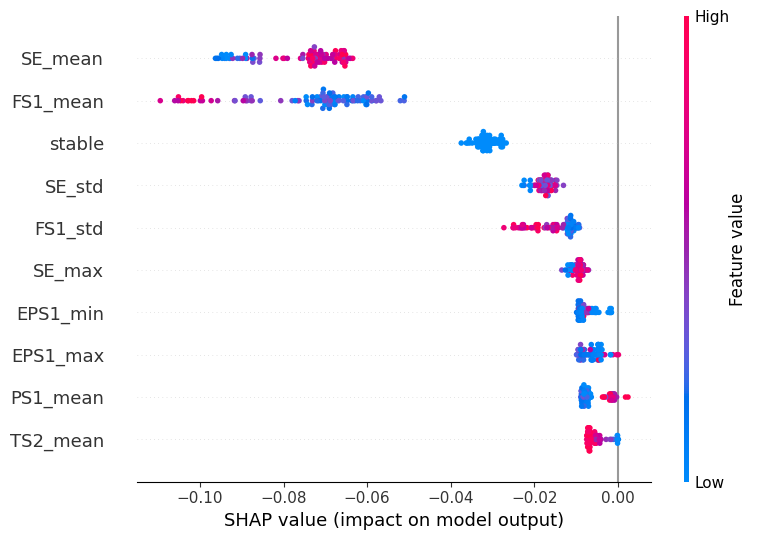

In [18]:
import shap
import joblib   
import matplotlib.pyplot as plt

# Load pump model
pump_model = joblib.load('../models/pump_model.pkl')

# Use Explainer instead of TreeExplainer
explainer = shap.Explainer(pump_model)

# Get SHAP values for first 100 cycles
sample = X_all.iloc[:100]
shap_values = explainer(sample)

print("SHAP values shape:", shap_values.shape)

# Plot feature importance for weak leakage (class 1)
print("\nTop 10 sensors driving WEAK LEAKAGE detection:")
shap.summary_plot(
    shap_values[:, :, 1],
    sample,
    feature_names=list(X_all.columns),
    max_display=10,
    show=True
)

In [19]:
import joblib

model = joblib.load('../models/pump_model.pkl')

In [20]:
y_accumulator = profile['accumulator']

In [21]:


# accum_model = RandomForestClassifier(
#     n_estimators=200,
#     class_weight='balanced',
#     random_state=42,
#     n_jobs=-1
# )

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = cross_val_score(
#     accum_model,
#     X_all,
#     y_accumulator,
#     cv=skf,
#     scoring='f1_macro',
#     n_jobs=-1
# )

# print("Accumulator 5-Fold CV:")
# for i, score in enumerate(scores):
#     print(f"Fold {i+1}: {score:.4f}")
# print(f"Mean: {scores.mean():.4f}")
# print(f"Std: {scores.std():.4f}")

# # Train and save
# accum_model.fit(X_all, y_accumulator)
# joblib.dump(accum_model, './models/accumulator_model.pkl')
# print("Accumulator model saved")

In [22]:
#Test

# Run this in a notebook cell
import pandas as pd
import numpy as np
import joblib

# X_all = pd.read_csv  # your feature matrix
# Or recreate it from your notebook

# Save 5 cycles as test upload
test_upload = X_all.iloc[:5].copy()
test_upload.to_csv('test_upload.csv', index=False)
print("Test CSV created with 5 cycles")

Test CSV created with 5 cycles


In [23]:
import sklearn
print(sklearn.__version__)

1.8.0


In [26]:
import pandas as pd

# Get some faulty cycles
pump_leakage = profile['pump_leakage']

# Find cycles with weak and severe leakage
weak_leakage_idx = pump_leakage[pump_leakage == 1].index[:2].tolist()
severe_leakage_idx = pump_leakage[pump_leakage == 2].index[:2].tolist()
healthy_idx = pump_leakage[pump_leakage == 0].index[:1].tolist()

# Combine
test_indices = healthy_idx + weak_leakage_idx + severe_leakage_idx
test_upload = X_all.iloc[test_indices].copy()
test_upload.to_csv('test_upload.csv', index=False)

print(f"Test file created with {len(test_upload)} cycles")
print("Expected: 1 healthy, 2 weak leakage, 2 severe leakage")

Test file created with 5 cycles
Expected: 1 healthy, 2 weak leakage, 2 severe leakage
